## Interpolation in PySPEDAS

PySPEDAS has several utilities for performing time interpolation on tplot variables or data arrays,
each of which performs similar operations, but with different options for input/output formats, NaN handling, interpolation methods, and data gap handling.  None of them were exactly equivalent to the IDL SPEDAS tinterpol_mxn routine, which is the most general-purpose interpolation tool available in that environment.

We have recently introduced the time_interpolate routine, which offers a superset of the features available in the other PySPEDAS interpolation tools, and is a near drop-in equivalent to tinterpol_mxn.  (PySPEDAS offers tinterpol_mxn as a wrapper arount time_interpolate, for convenient
porting of IDL SPEDAS workflows to Python.

This notebook demonstrates the capabilities of time_interpolate, and how they compare to the older interpolation routines.

We'll start by installing PySPEDAS, if needed.  Then we'll load some data to work with.

In [1]:
# This line installs PySPEDAS, to allow this notebook to run in a Google Colab environment.
# It can be skipped or commented out if you already have PySPEDAS 2.2.0 or above installed.
! pip install "pyspedas[all]>=2.2.0"

  Obtaining dependency information for pyspedas[all]>=2.2.0 from https://files.pythonhosted.org/packages/cc/48/c76d8d7052fc18d635746bf1f65bfa9acf6c7e28925547076462b65e206c/pyspedas-2.2.0-py3-none-any.whl.metadata
  Obtaining dependency information for requests>=2.34.2 from https://files.pythonhosted.org/packages/a0/f4/c67b0b3f1b9245e8d266f0f112c500d50e5b4e83cb6f3b71b6528104182a/requests-2.34.2-py3-none-any.whl.metadata
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Obtaining dependency information for cdasws>=1.8.18 from https://files.pythonhosted.org/packages/af/b1/68c6af91ce9980e4a775ab5fd44f11c55026f8cfb513fd0b6e34cb1d3c0a/cdasws-1.8.18-py3-none-any.whl.metadata
  Obtaining dependency information for tomlkit>=0.13.0 from https://files.pythonhosted.org/packages/13/bc/8c13eb66537dce1d2bd3a57132902f38d0e7f5bb46fa9f4daed9fe9d76ee/tomlkit-0.15.1-py3-none-any.whl.metadata
  Obtaining dependency information for bottleneck>=1.3.7 from https://files.pythonhosted.org/pack

22-Sep-26 12:01:57: File is current: themis_data/tha/l1/state/2007/tha_l1_state_20070323.cdf


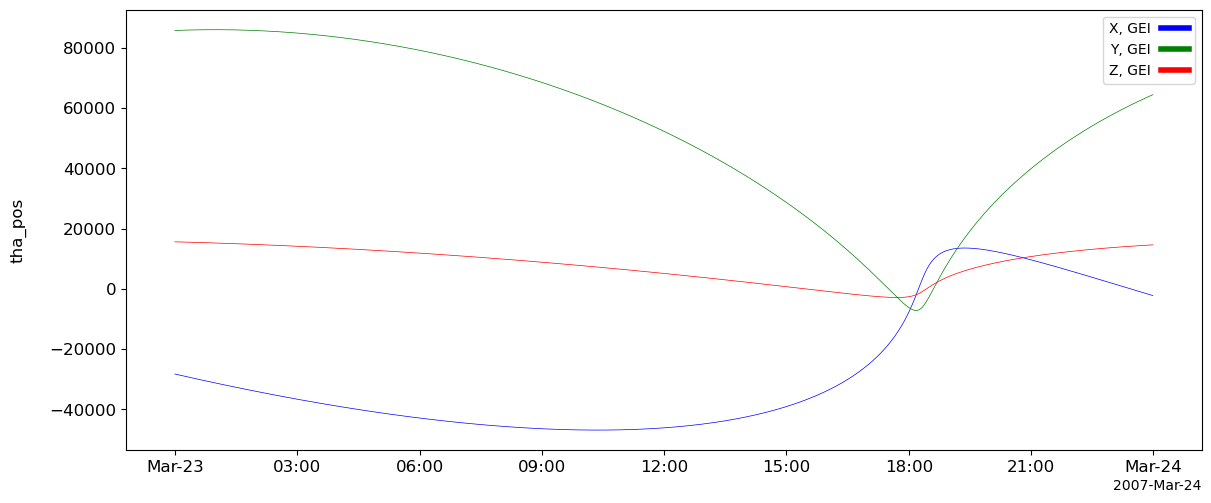

In [2]:
from pyspedas import *
from pyspedas.projects.themis import state
import numpy as np

# The full resolution ephemeris (one sample per minute)

trange=['2007-03-23','2007-03-24']
state(probe='a',trange=trange)

tplot('tha_pos')

Now we'll use time_interpolate to resample the ephemeris at 10 minute intervals.

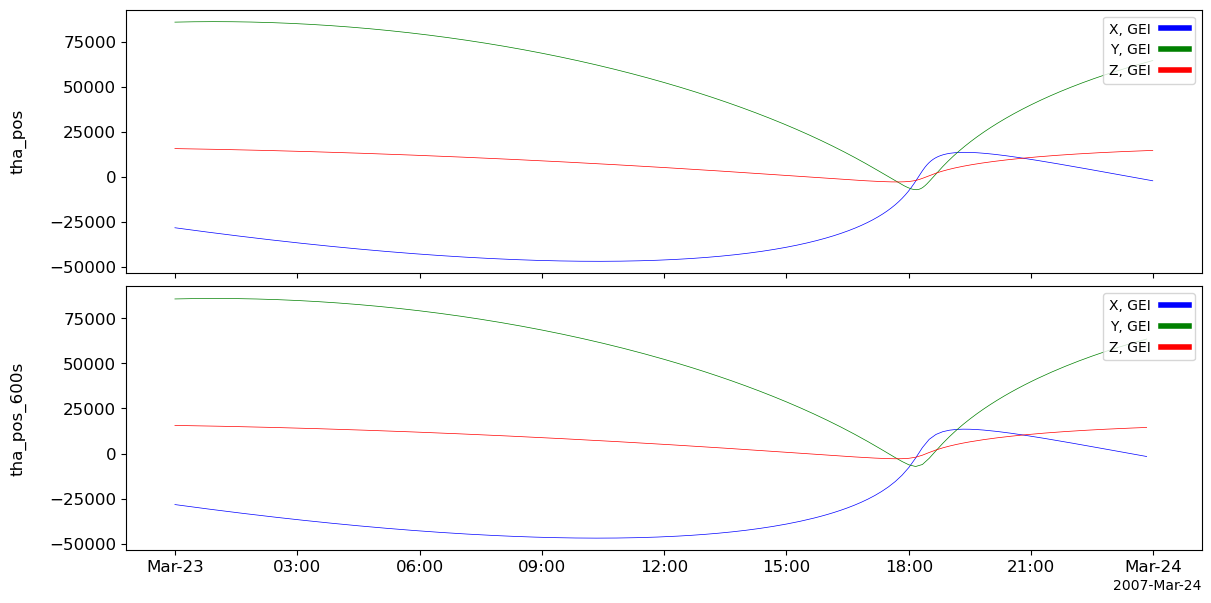

In [3]:
# Calculate a new time grid, covering the original 24-hour trange, with points every 600 sec

newtimes = time_double(trange[0]) + 600.0*np.array(range(24*6))

time_interpolate('tha_pos', newtimes, newname='tha_pos_600s')

tplot('tha_pos tha_pos_600s')

What if we try to extrapolate beyond the original 24 hour interval?

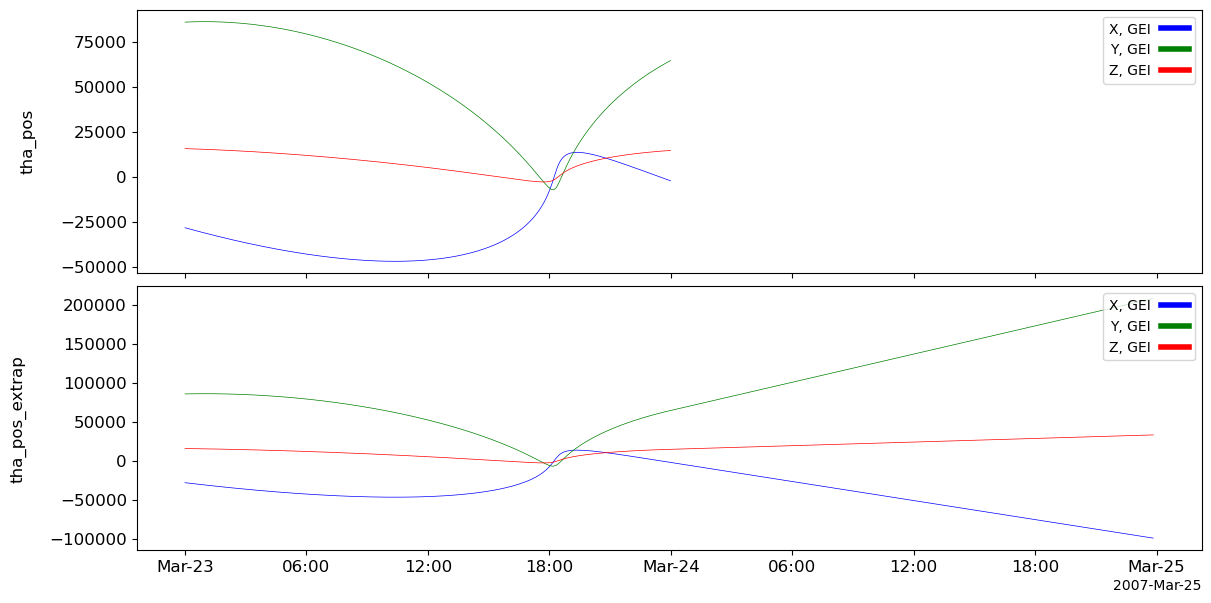

In [4]:
newtimes = time_double(trange[0]) + 600.0*np.array(range(48*6))

time_interpolate('tha_pos', newtimes, newname='tha_pos_extrap')

tplot('tha_pos tha_pos_extrap')

By default, time_interpolate will extrapolate beyond the bounds of the original time range.  In this case, we're using the default 'linear' method.  This can be disabled with the 'no_extrapolate' boolean option, which ignores grid times outside the range of the input times.

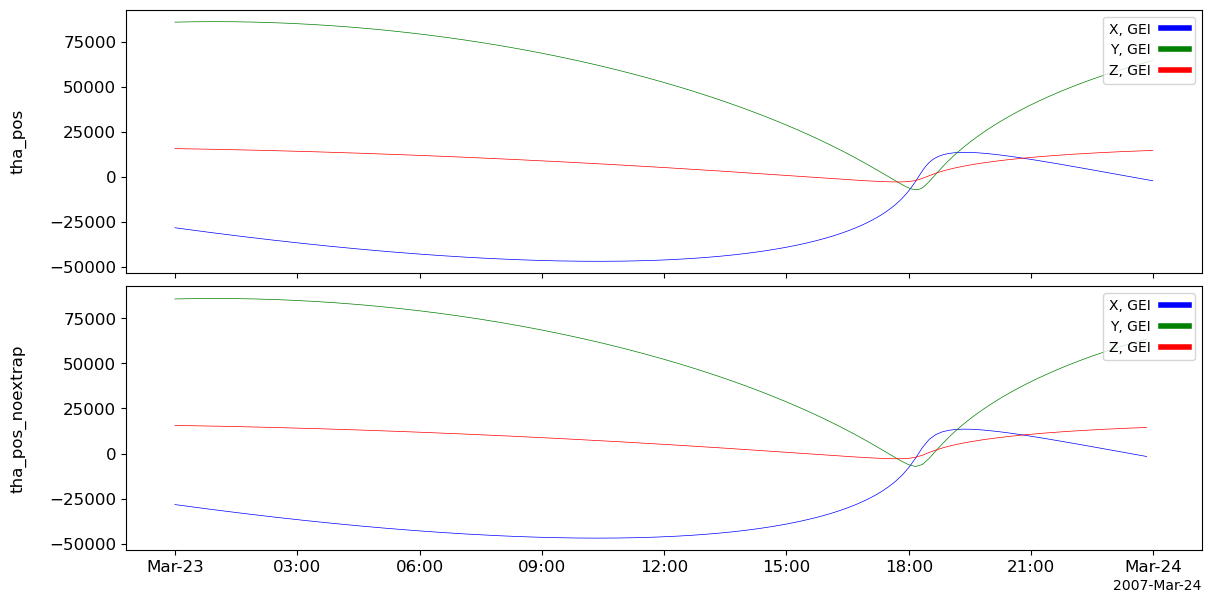

In [5]:
time_interpolate('tha_pos', newtimes, no_extrapolate=True, newname='tha_pos_noextrap')
tplot('tha_pos tha_pos_noextrap')

There are also options to NaN-fill times outside the input range, or repeat the boundary point.

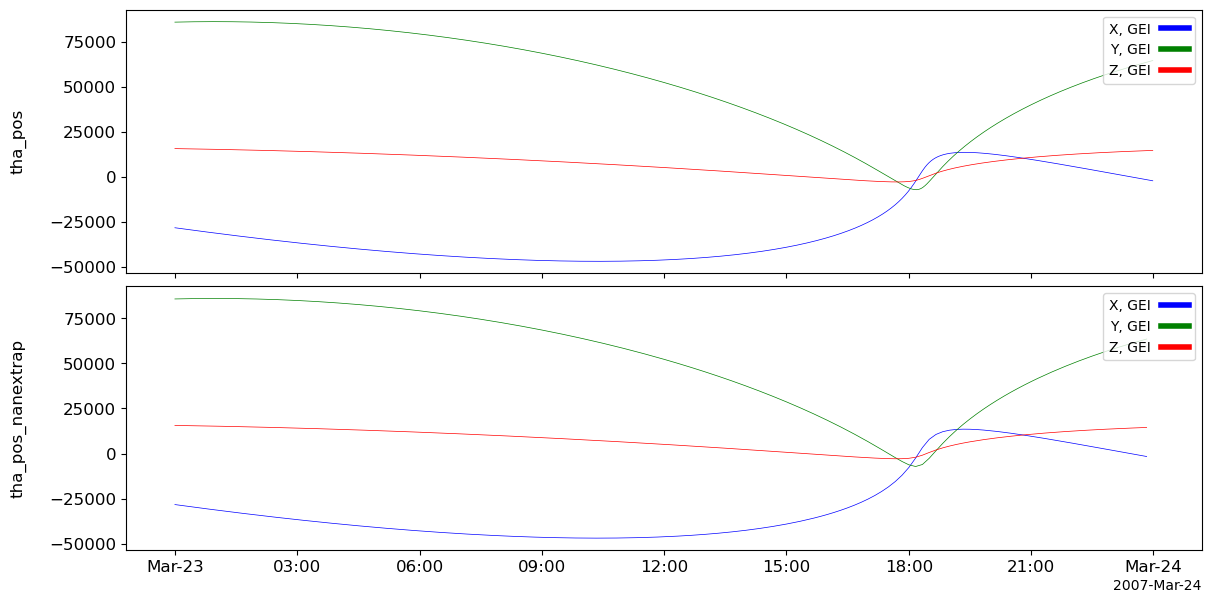

Last extrapolated sample time: 2007-03-24 23:50:00.000000, last data point [nan nan nan]


In [6]:
time_interpolate('tha_pos', newtimes, nan_extrapolate=True, newname='tha_pos_nanextrap')
tplot('tha_pos tha_pos_nanextrap')

# tplot doesn't show the extrapolated NaNs, but they are there
nan_data = get_data('tha_pos_nanextrap')
last_timestamp=time_string(nan_data.times[-1])
last_data=nan_data.y[-1,:]
print(f"Last extrapolated sample time: {last_timestamp}, last data point {last_data}")

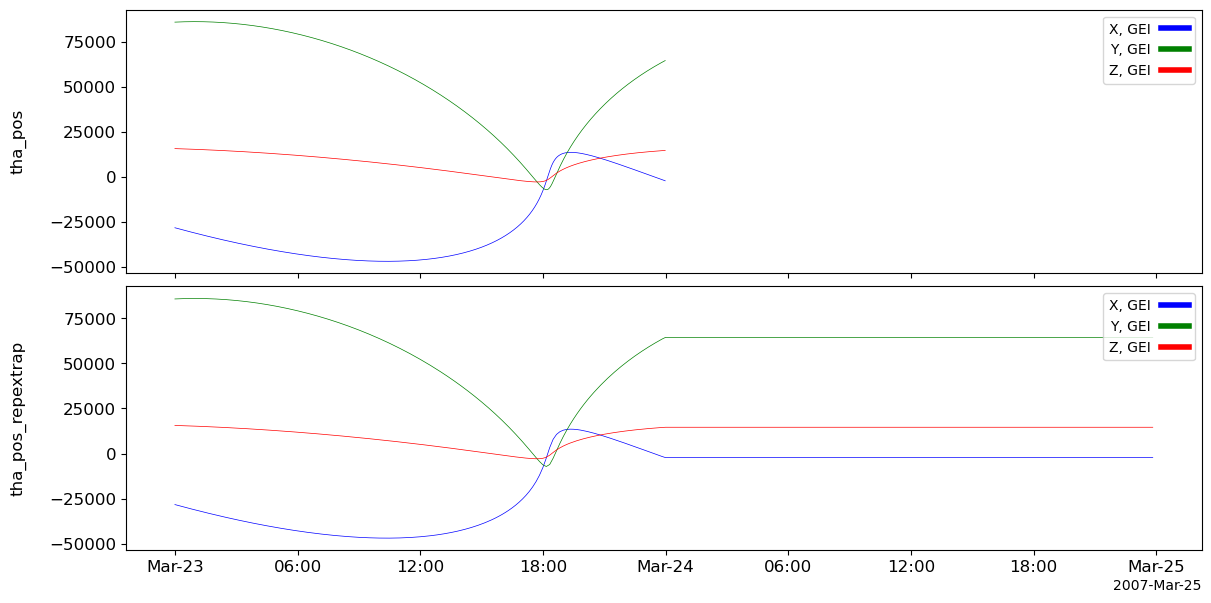

In [7]:
time_interpolate('tha_pos', newtimes, repeat_extrapolate=True, newname='tha_pos_repextrap')
tplot('tha_pos tha_pos_repextrap')


## Interpolation methods

`time_interpolate` supports `linear`, `quadratic`, `spline`, `nearest`, and `previous`. Linear is a strong default for continuous measurements. Nearest selects an observed value. Previous is sample-and-hold and is usually right for flags and instrument modes. Quadratic uses a local three-point polynomial; spline uses a natural cubic spline over each local four-point neighborhood. Higher-order curves may overshoot, so smoothness is not automatically more physical.

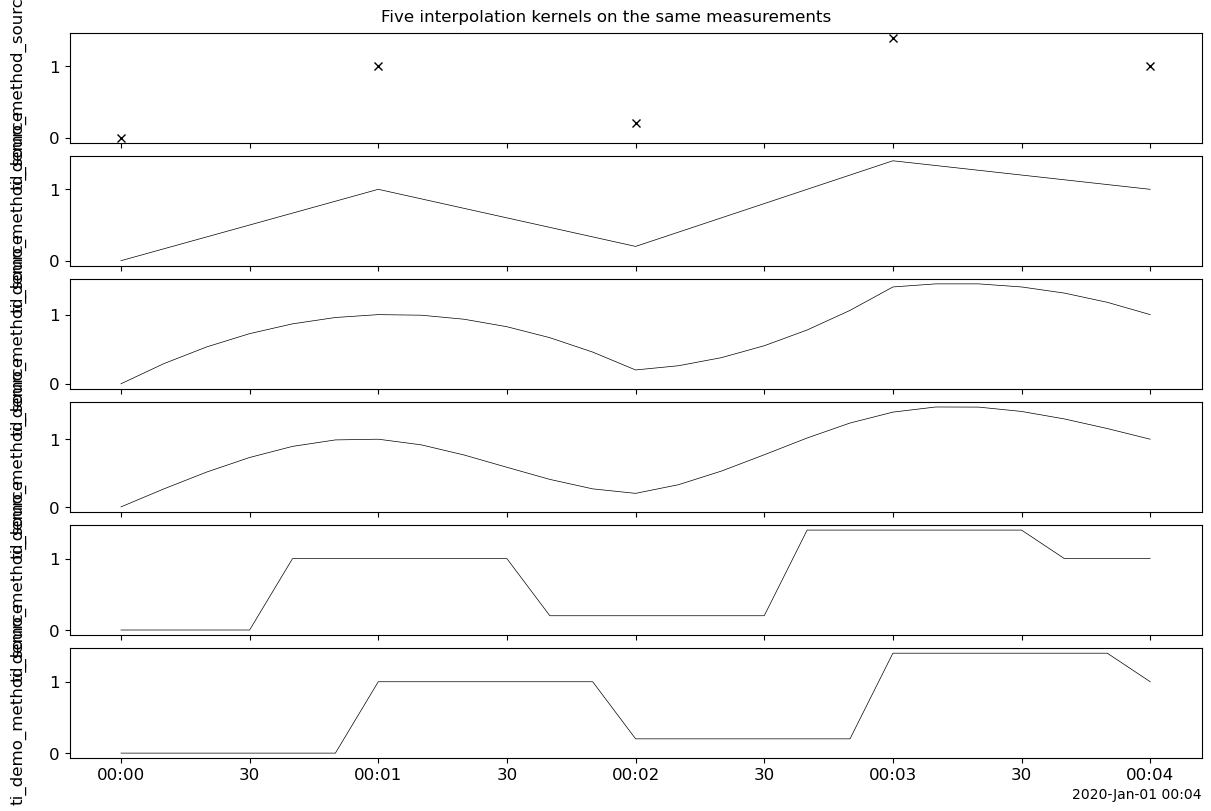

In [8]:
method_t0 = time_double("2020-01-01T00:00:00")
method_times = method_t0 + np.array([0, 60, 120, 180, 240], dtype=float)
method_values = np.array([0.0, 1.0, 0.2, 1.4, 1.0])
method_grid = method_t0 + np.arange(0, 241, 10.0)
store_data("ti_demo_method_source", data={"x": method_times, "y": method_values})
method_names = []
for method in ["linear", "quadratic", "spline", "nearest", "previous"]:
    name = f"ti_demo_{method}"
    time_interpolate("ti_demo_method_source", method_grid, method=method, newname=name)
    method_names.append(name)
options("ti_demo_method_source", "marker", "x")
options("ti_demo_method_source", "line_style_name", "none")
tplot_options("title", "Five interpolation kernels on the same measurements")
tplot(["ti_demo_method_source", *method_names])

## Arrays, matrices, and tensors

Pass a dictionary containing `x` and `y` to work without tplot storage. The first Y dimension is time and any number of trailing dimensions is retained. Static coordinates may be supplied as `v`, `v1`, `v2`, or `v3`. With no `newname`, the result is a dictionary with `datetime64[ns]` times. Matrix elements are independent; interpolation does not preserve constraints such as rotation-matrix orthogonality.

In [9]:
array_source = {
    "x": [0, 2, 5],
    "y": np.array([
        [[0.0, 10.0], [20.0, 30.0]],
        [[2.0, 12.0], [22.0, 32.0]],
        [[5.0, 15.0], [25.0, 35.0]],
    ]),
    "v1": ["row_0", "row_1"], "v2": ["column_0", "column_1"],
}
array_result = time_interpolate(array_source, [1, 3, 4])
print("x dtype:", array_result["x"].dtype)
print("input/output y:", array_source["y"].shape, array_result["y"].shape)
print("one interpolated matrix:\n", array_result["y"][1])
time_interpolate(array_source, [1, 3, 4], newname="ti_demo_matrix")
pos_dict = time_interpolate("tha_pos", newtimes[:3], return_data=True)
print("returned tplot keys:", sorted(pos_dict))

x dtype: datetime64[ns]
input/output y: (3, 2, 2) (3, 2, 2)
one interpolated matrix:
 [[ 3. 13.]
 [23. 33.]]
returned tplot keys: ['metadata', 'v', 'x', 'y']


## NaN handling

NaNs propagate through the interpolation neighborhood by default. `ignore_nans=True` removes them independently per component before fitting. That repairs isolated dropouts but can bridge long missing intervals. `max_gap_samples` bounds consecutive missing **source** samples; it never counts output samples and does not enable NaN removal by itself.

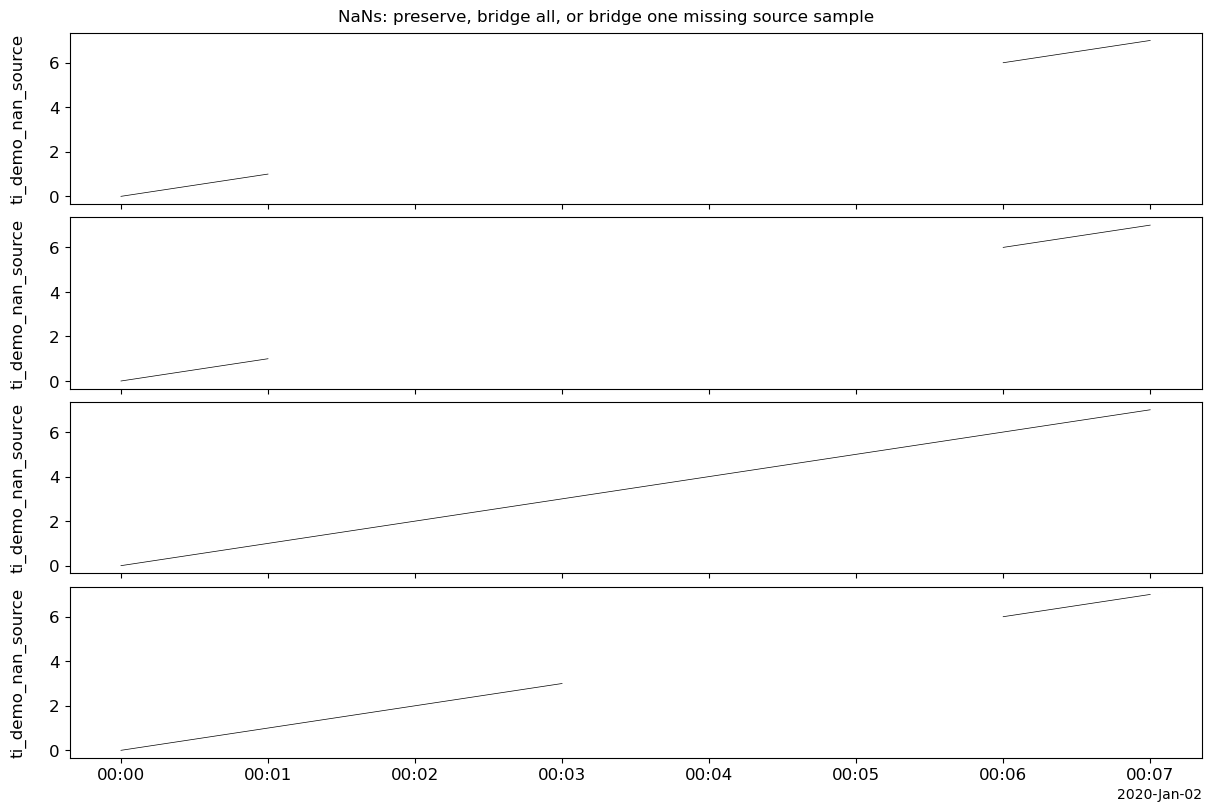

ti_demo_nan_preserved         finite= 7/15
ti_demo_nan_bridge_all        finite=15/15
ti_demo_nan_bridge_one        finite=10/15


In [10]:
nan_t0 = time_double("2020-01-02T00:00:00")
nan_times = nan_t0 + 60.0*np.arange(8)
nan_values = np.array([0.0, 1.0, np.nan, 3.0, np.nan, np.nan, 6.0, 7.0])
nan_grid = nan_t0 + 30.0*np.arange(15)
store_data("ti_demo_nan_source", data={"x": nan_times, "y": nan_values})
time_interpolate("ti_demo_nan_source", nan_grid, newname="ti_demo_nan_preserved")
time_interpolate("ti_demo_nan_source", nan_grid, ignore_nans=True,
                 newname="ti_demo_nan_bridge_all")
time_interpolate("ti_demo_nan_source", nan_grid, ignore_nans=True,
                 max_gap_samples=1, newname="ti_demo_nan_bridge_one")
tplot_options("title", "NaNs: preserve, bridge all, or bridge one missing source sample")
tplot(["ti_demo_nan_source", "ti_demo_nan_preserved",
       "ti_demo_nan_bridge_all", "ti_demo_nan_bridge_one"])
for name in ["ti_demo_nan_preserved", "ti_demo_nan_bridge_all", "ti_demo_nan_bridge_one"]:
    y = get_data(name).y
    print(f"{name:29s} finite={np.isfinite(y).sum():2d}/{y.size}")

## Acquisition gaps without NaN records

A series can jump between valid records across an outage. `max_gap_time` limits the seconds between the valid samples surrounding a target. Interior targets in a longer interval become NaN; exact source samples remain valid. When both gap limits are set, exceeding either rejects the interval. Equality with `max_gap_time` is allowed.

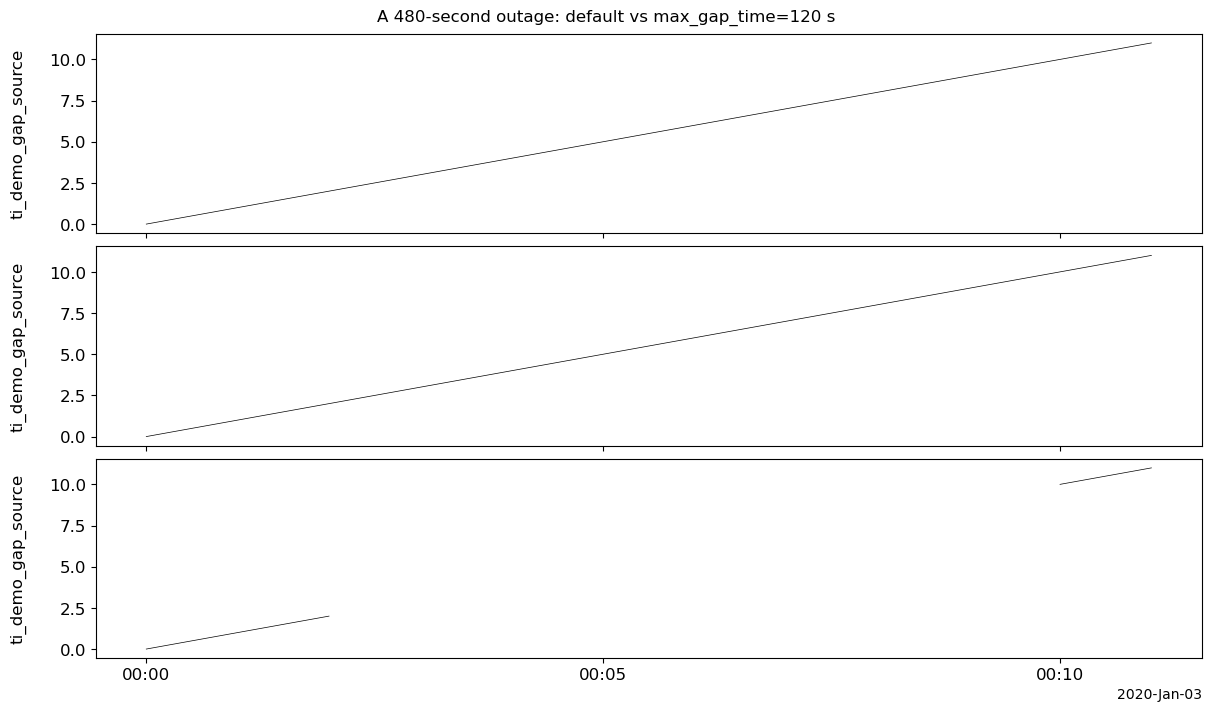

In [11]:
gap_t0 = time_double("2020-01-03T00:00:00")
gap_times = gap_t0 + np.array([0, 60, 120, 600, 660], dtype=float)
gap_values = np.array([0.0, 1.0, 2.0, 10.0, 11.0])
gap_grid = gap_t0 + np.arange(0, 661, 30.0)
store_data("ti_demo_gap_source", data={"x": gap_times, "y": gap_values})
time_interpolate("ti_demo_gap_source", gap_grid, newname="ti_demo_gap_unbounded")
time_interpolate("ti_demo_gap_source", gap_grid, max_gap_time=120.0,
                 newname="ti_demo_gap_guarded")
tplot_options("title", "A 480-second outage: default vs max_gap_time=120 s")
tplot(["ti_demo_gap_source", "ti_demo_gap_unbounded", "ti_demo_gap_guarded"])

## THEMIS L2 ESA spectrograms

ESA energy-flux products are a realistic multidimensional example. Energy bins may vary with time. Y uses the selected interpolation method, while time-dependent bin maps use **previous-map** semantics: each target gets the latest source map. Bin maps are not blended and Y is not physically rebinned. This interval and these products also appear in the plotting test suite.

22-Sep-26 12:01:59: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/tha/l2/esa/2007/
22-Sep-26 12:02:00: File is current: themis_data/tha/l2/esa/2007/tha_l2_esa_20070323_v01.cdf
22-Sep-26 12:02:00: specplot: Sorting input_bin_centers for variable tha_peif_en_eflux


Loaded: ['tha_peif_en_eflux', 'tha_peib_en_eflux']


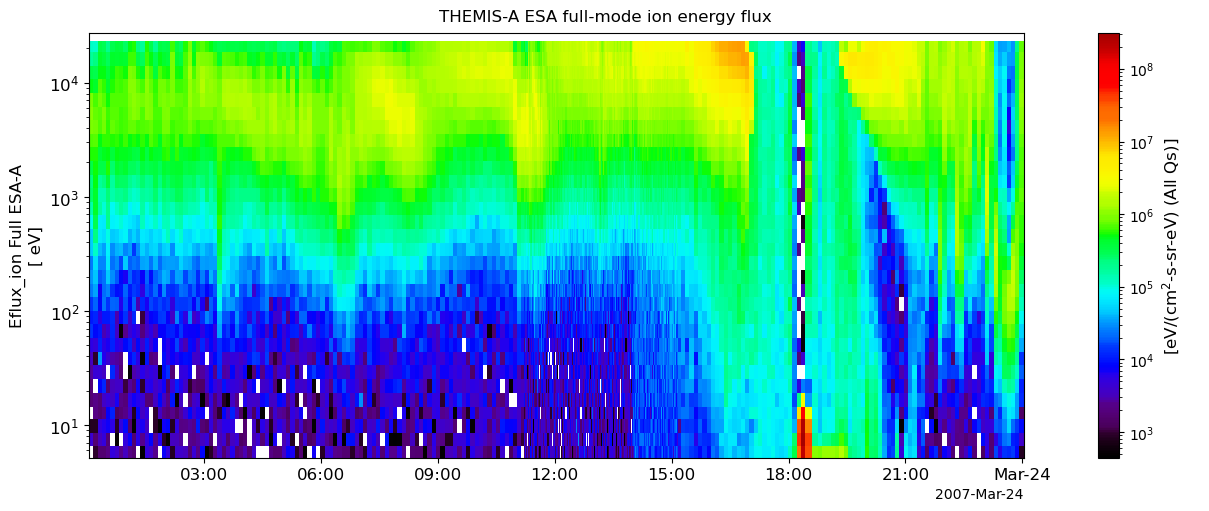

In [12]:
from pyspedas.projects.themis import esa
esa_vars = esa(
    probe="a", trange=trange, level="l2",
    varnames=["tha_peif_en_eflux", "tha_peib_en_eflux"], time_clip=True,
)
print("Loaded:", esa_vars)
assert data_exists("tha_peif_en_eflux") and data_exists("tha_peib_en_eflux")
options("tha_peif_en_eflux", "sort_spec_bins", True)
tplot_options("title", "THEMIS-A ESA full-mode ion energy flux")
tplot("tha_peif_en_eflux")

### Use a tplot variable as the target clock

Only the target variable's timestamps are used. Here ESA is put on the one-minute ephemeris clock for a joint plasma/position workflow. `nan_extrapolate` keeps the full target clock and marks targets outside ESA coverage.

22-Sep-26 12:02:01: specplot: Sorting input_bin_centers for variable tha_peif_en_eflux
22-Sep-26 12:02:01: specplot: Sorting input_bin_centers for variable ti_demo_peif_on_pos_times
22-Sep-26 12:02:01: specplot_make_1d_ybins: Direction of increase of input bin centers was indeterminate (all-nan, all-same, or non-monotonic) at 8 of 1440 time indices.


native/resampled y: (326, 32) (1440, 32)
resampled bin map: (1440, 32)


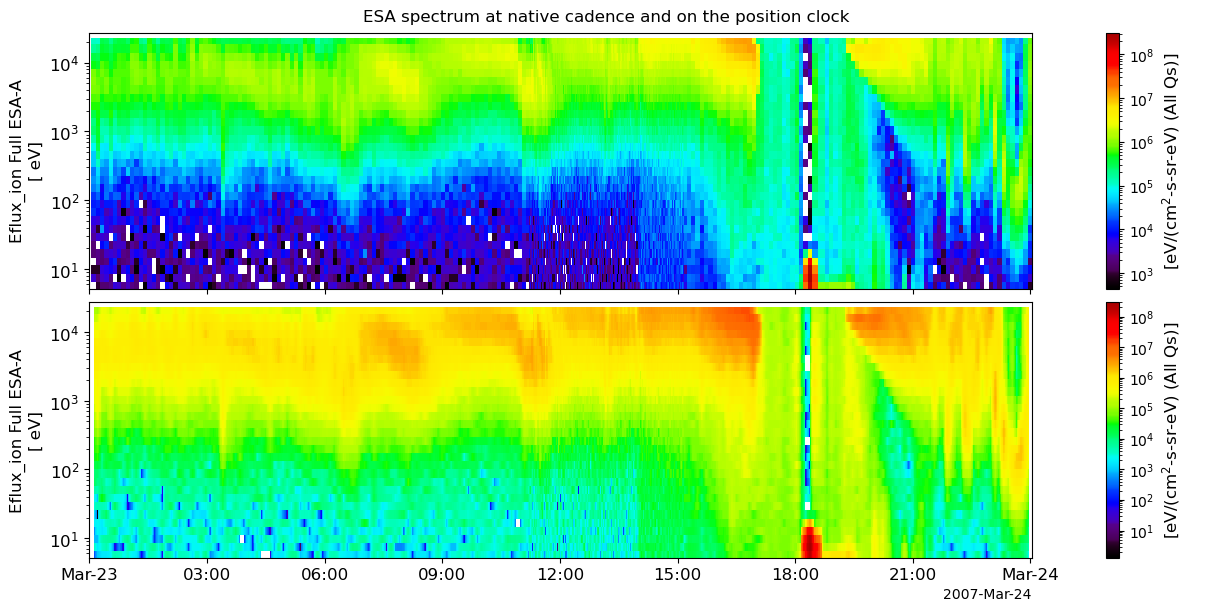

In [13]:
time_interpolate(
    "tha_peif_en_eflux", "tha_pos", method="linear",
    nan_extrapolate=True, newname="ti_demo_peif_on_pos_times",
)
options("ti_demo_peif_on_pos_times", "sort_spec_bins", True)
native, aligned = get_data("tha_peif_en_eflux"), get_data("ti_demo_peif_on_pos_times")
print("native/resampled y:", native.y.shape, aligned.y.shape)
print("resampled bin map:", np.shape(getattr(aligned, "v", None)))
tplot_options("title", "ESA spectrum at native cadence and on the position clock")
tplot(["tha_peif_en_eflux", "ti_demo_peif_on_pos_times"])

## Burst gaps: expose them, then refuse to bridge them

ESA burst intervals are separated by long periods with no acquisition. The plotting tests use `degap(..., dt=4.0)` so inserted NaNs keep bursts visibly separate. For resampling, `ignore_nans=True` alone may remove those markers and bridge separate bursts. A time guard preserves the difference between adjacent records and continuous observation.

22-Sep-26 12:02:02: specplot: Sorting input_bin_centers for variable ti_demo_peib_raw
22-Sep-26 12:02:02: specplot: Sorting input_bin_centers for variable ti_demo_peib_degapped
22-Sep-26 12:02:02: specplot_make_1d_ybins: Direction of increase of input bin centers was indeterminate (all-nan, all-same, or non-monotonic) at 2643 of 3033 time indices.


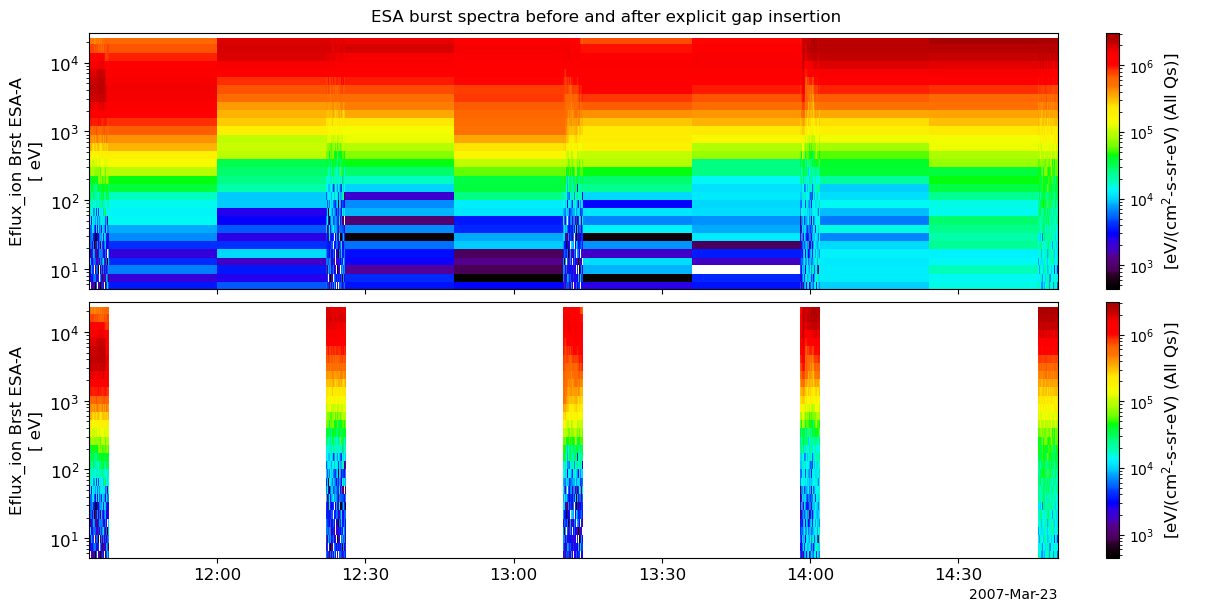

In [14]:
tplot_copy("tha_peib_en_eflux", new_name="ti_demo_peib_raw")
degap("ti_demo_peib_raw", dt=4.0, newname="ti_demo_peib_degapped")
options("ti_demo_peib_raw", "sort_spec_bins", True)
options("ti_demo_peib_degapped", "sort_spec_bins", True)
tplot_options("title", "ESA burst spectra before and after explicit gap insertion")
tplot(["ti_demo_peib_raw", "ti_demo_peib_degapped"])

22-Sep-26 12:02:02: specplot: Sorting input_bin_centers for variable ti_demo_peib_degapped
22-Sep-26 12:02:02: specplot_make_1d_ybins: Direction of increase of input bin centers was indeterminate (all-nan, all-same, or non-monotonic) at 2643 of 3033 time indices.
22-Sep-26 12:02:02: specplot: Sorting input_bin_centers for variable ti_demo_peib_bridge_all
22-Sep-26 12:02:02: specplot_make_1d_ybins: Direction of increase of input bin centers was indeterminate (all-nan, all-same, or non-monotonic) at 312 of 326 time indices.
22-Sep-26 12:02:02: specplot: Sorting input_bin_centers for variable ti_demo_peib_gap_protected
22-Sep-26 12:02:02: specplot_make_1d_ybins: Direction of increase of input bin centers was indeterminate (all-nan, all-same, or non-monotonic) at 312 of 326 time indices.


ti_demo_peib_bridge_all         rows with data=  119/326
ti_demo_peib_gap_protected      rows with data=   14/326


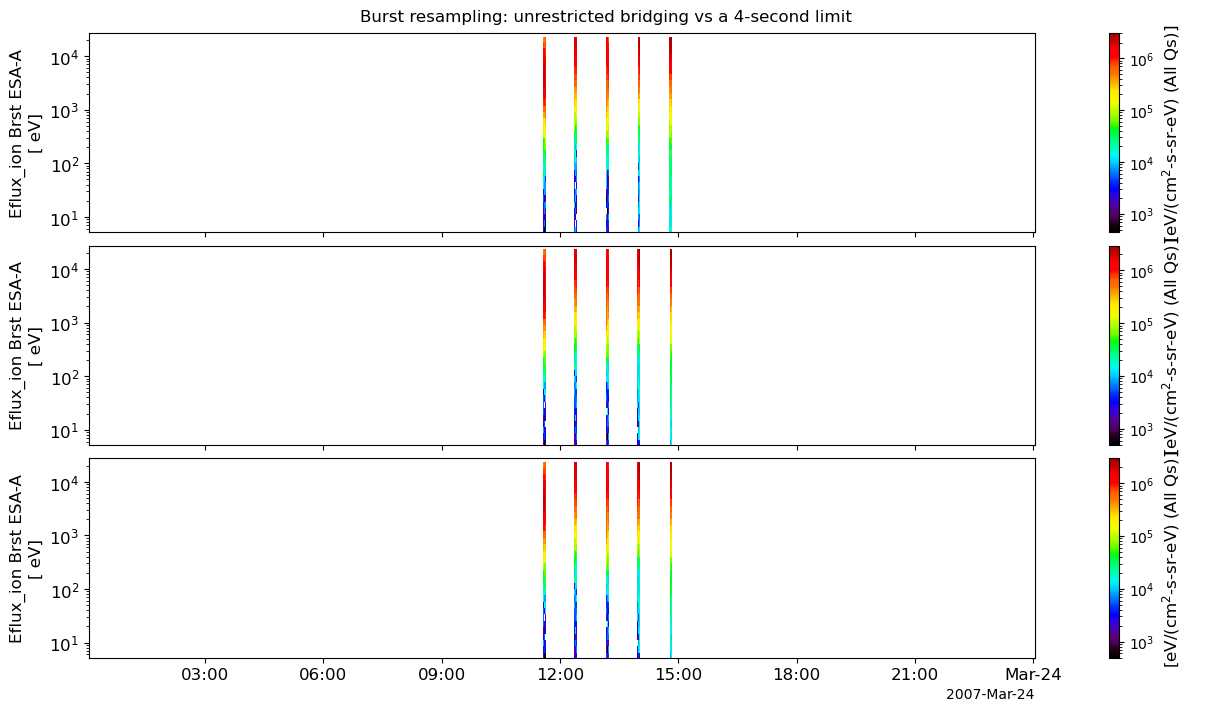

In [15]:
# Full mode supplies only a continuous target clock.
time_interpolate(
    "ti_demo_peib_degapped", "tha_peif_en_eflux",
    ignore_nans=True, nan_extrapolate=True, newname="ti_demo_peib_bridge_all",
)
time_interpolate(
    "ti_demo_peib_degapped", "tha_peif_en_eflux",
    ignore_nans=True, max_gap_time=4.0, nan_extrapolate=True,
    newname="ti_demo_peib_gap_protected",
)
for name in ["ti_demo_peib_bridge_all", "ti_demo_peib_gap_protected"]:
    options(name, "sort_spec_bins", True)
    y = get_data(name).y
    finite_rows = np.any(np.isfinite(y), axis=tuple(range(1, y.ndim)))
    print(f"{name:31s} rows with data={finite_rows.sum():5d}/{len(finite_rows)}")
tplot_options("title", "Burst resampling: unrestricted bridging vs a 4-second limit")
tplot(["ti_demo_peib_degapped", "ti_demo_peib_bridge_all",
       "ti_demo_peib_gap_protected"])

The protected result is safer for burst science: interpolation is allowed within a burst when surrounding records are at most four seconds apart, but a longer outage stays NaN. Derive the threshold from instrument cadence and the physical scale; do not copy `4.0` blindly to another product.

## Batch operations, target formats, and decision guide

A source may be one tplot name, a list, or a wildcard. Batch output can use a common `suffix`, an explicit `newname` list, or `overwrite=True`; these naming modes are mutually exclusive. Targets may be Unix seconds, ISO strings, NumPy datetimes, or a tplot name. Target order and duplicates are preserved. Source times must be strictly monotonic; descending sources are reversed and duplicate source times are rejected.

| Workflow | Recommended start |
|---|---|
| Continuous measurement | `method="linear"` |
| Flag, mode, or state | `method="previous"` |
| Fixed target clock | `nan_extrapolate=True` |
| Short NaN runs | `ignore_nans=True, max_gap_samples=...` |
| Acquisition outages | `max_gap_time=...` |
| Changing spectral bins | Previous bin maps; Y is not rebinned |
| No tplot storage | Dictionary input or `return_data=True` |

Exact valid samples are copied. All-NaN components stay NaN. Quadratic needs three usable samples and spline four; smaller sets fall back to linear or constant behavior. Gap limits apply to interior targets but do not replace an extrapolation policy.

In [16]:
batch_names = time_interpolate(
    ["tha_pos", "tha_vel"],
    np.arange(time_double(trange[0]), time_double(trange[1]), 600.0),
    suffix="_ti_demo_600s",
)
print("Batch outputs:", batch_names)
format_result = time_interpolate(
    {"x": ["2020-01-04T00:00:00Z", "2020-01-04T00:01:00Z",
           "2020-01-04T00:02:00Z"], "y": [0.0, 1.0, 2.0]},
    ["2020-01-04T00:01:30Z", "2020-01-04T00:00:30Z",
     "2020-01-04T00:01:30Z"],
)
print(format_result["x"].astype("datetime64[ms]").astype(str))
print(format_result["y"])

Batch outputs: ['tha_pos_ti_demo_600s', 'tha_vel_ti_demo_600s']
['2020-01-04T00:01:30.000' '2020-01-04T00:00:30.000'
 '2020-01-04T00:01:30.000']
[1.5 0.5 1.5]


Before using interpolated data in a physical calculation, plot source and result, count finite values, and choose gap limits from cadence and scientific time scale.
